# **Week3 복습과제**



이번 복습과제에서는 두 가지 레이어에 대한 내용을 다룹니다. `ReLU 활성화 함수와 조합된 convolution layer`와 `maximum pooling layer`입니다.
각각에 대해 알아보고 사진에 적용하는 실습을 해보겠습니다.

Convolution layer, ReLU 활성화 함수, 그리고 maximum pooling layer는 특성 추출 과정에서 각각 다음과 같은 역할을 합니다.
- 이미지를 특정 특징에 맞게 필터링  ->  Convolution Layer
- 필터링된 이미지에서 해당 특징을 감지  ->  ReLU Activation Function
- 특징을 강조하기 위해 이미지를 압축  ->  Maximum Pooling Layer

아래 이미지에서는 이 세 가지 연산이 원본 이미지의 가로 선 특징을 추출해낸 것을 볼 수 있습니다.
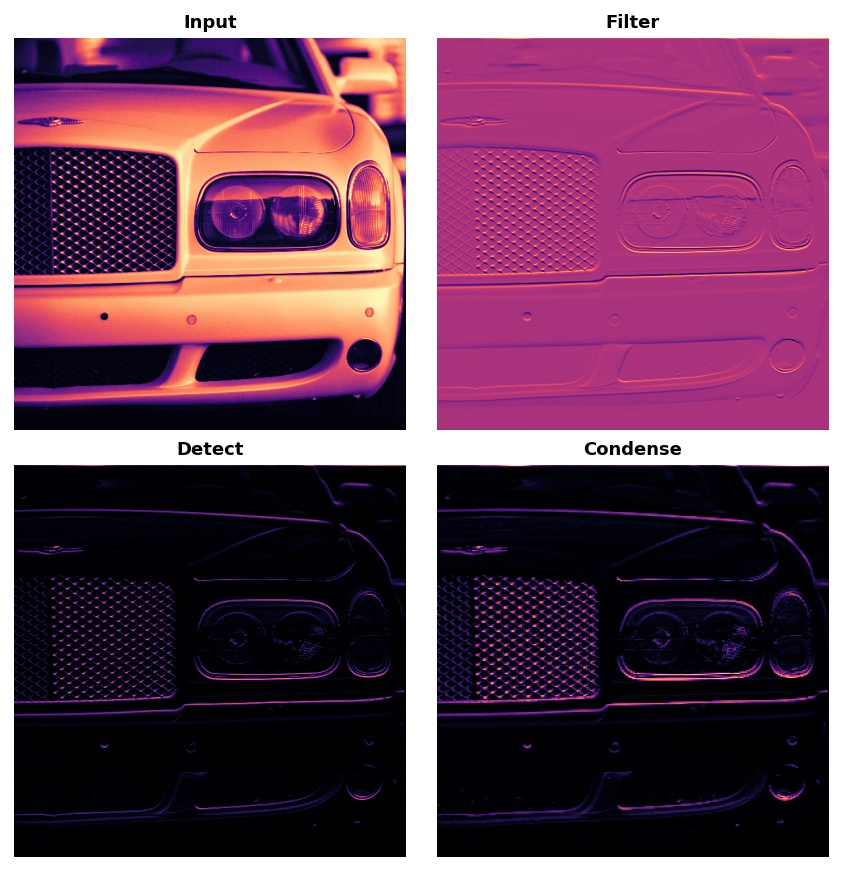



<a id="1"></a> <br>
## 1. Convolution Layer

- Convolution layer는 keras 모델에서 아래의 코드와 같이 정의할 수 있습니다.

 - keras 모델은 keras 라이브러리를 사용하여 구축된 딥러닝 모델을 말합니다.
 - 복잡한 신경망 모델을 간단한 코드로 만들 수 있게 도와줍니다.
   - `Conv2D` layer를 설정해주세요.




In [2]:
from tensorflow import keras
from tensorflow.keras import layers

model = keras.Sequential([
    layers.Conv2D(filters=64, kernel_size=3), # 활성화 함수 X
    # 더 많은 레이어가 추가될 수 있습니다.
    # 은닉층, 추가 컨볼루션층, 출력층 등.
])

<a id="1"></a> <br>
## 2. ReLU Activation Function

- 위의 convolution layer에 ReLU를 적용시켜봅시다.

In [3]:
model = keras.Sequential([
    layers.Conv2D(filters=64, kernel_size=3, activation='relu') # 활성화 함수로 ReLU가 선택된 것을 볼 수 있음.
    # 더 많은 레이어가 추가될 수 있습니다.
])

<a id="1"></a> <br>
## 3. Maximum Pooling Layer

- 앞서 구축한 keras 모델에 maximum pooling layer를 추가해봅시다.
 - keras에서는 `MaxPool2D` layer가 사용됩니다.

In [4]:
from tensorflow import keras
from tensorflow.keras import layers

model = keras.Sequential([
    layers.Conv2D(filters=64, kernel_size=3),
    layers.MaxPool2D(pool_size=2),
    # 더 많은 레이어가 추가될 수 있습니다.
])

<a id="1"></a> <br>
## 4. 예제

- 예제에서는 Convolution layer가 안 보이는 곳에서 수행하는 작업을 더 잘 이해하기 위해 직접 특징 추출 과정을 진행해보겠습니다.
 - 첨부된 이미지 파일을 준비해주세요.

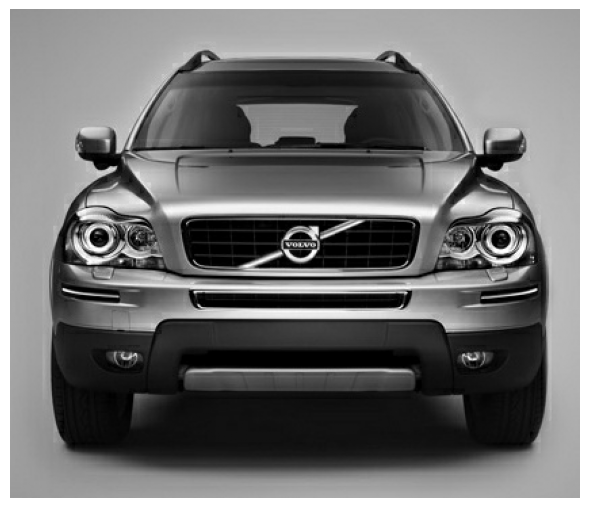

In [6]:
# 이 셀을 실행시켜주세요!
import tensorflow as tf
import matplotlib.pyplot as plt
plt.rc('figure', autolayout=True)
plt.rc('axes', labelweight='bold', labelsize='large',
       titleweight='bold', titlesize=18, titlepad=10)
plt.rc('image', cmap='magma')

image_path = './car_feature.jpg'  #첨부된 이미지 파일을 사용해주세요
image = tf.io.read_file(image_path)
image = tf.io.decode_jpeg(image)

plt.figure(figsize=(6, 6))
plt.imshow(tf.squeeze(image), cmap='gray')
plt.axis('off')
plt.show();

In [7]:
# 이 셀을 실행해주세요!
import numpy as np
from itertools import product

def show_kernel(kernel, label=True, digits=None, text_size=28):
    # Format kernel
    kernel = np.array(kernel)
    if digits is not None:
        kernel = kernel.round(digits)

    # Plot kernel
    cmap = plt.get_cmap('Blues_r')
    plt.imshow(kernel, cmap=cmap)
    rows, cols = kernel.shape
    thresh = (kernel.max()+kernel.min())/2
    # Optionally, add value labels
    if label:
        for i, j in product(range(rows), range(cols)):
            val = kernel[i, j]
            color = cmap(0) if val > thresh else cmap(255)
            plt.text(j, i, val,
                     color=color, size=text_size,
                     horizontalalignment='center', verticalalignment='center')
    plt.xticks([])
    plt.yticks([])

#### **Kernel로 필터링**
- 필터링 단계에서는 kernel을 직접 정의한 후 convolution을 사용하여 적용하겠습니다.
- 이렇게 하면 TensorFlow에서 사용하는 **텐서(tensor)** 형태로 커널이 생성됩니다.

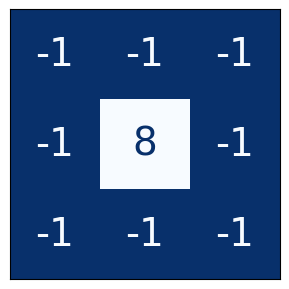

In [8]:
import tensorflow as tf

kernel = tf.constant([
    [-1, -1, -1],
    [-1,  8, -1],
    [-1, -1, -1],
])

plt.figure(figsize=(3, 3))
show_kernel(kernel)

In [9]:
# 이 셀을 실행해주세요!
image = tf.image.convert_image_dtype(image, dtype=tf.float32)
image = tf.expand_dims(image, axis=0)
kernel = tf.reshape(kernel, [*kernel.shape, 1, 1])
kernel = tf.cast(kernel, dtype=tf.float32)

- 이제 커널을 이미지에 적용시켜봅시다.
 - `input=image`
 - `filters=kernel`

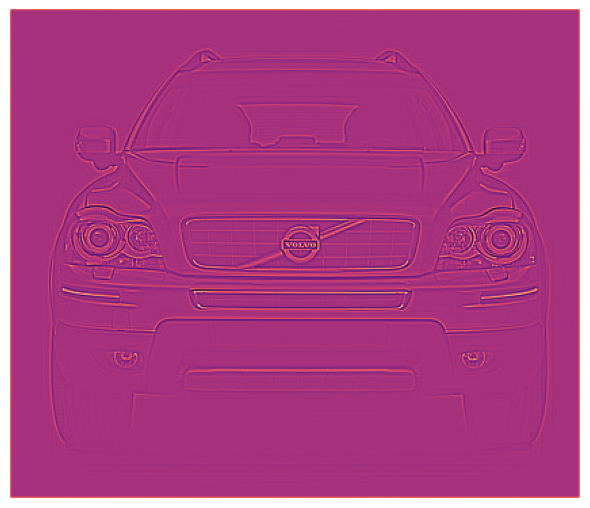

In [10]:
image_filter = tf.nn.conv2d(
    input=image,
    filters=kernel,
    strides=1,
    padding='SAME',
)

plt.figure(figsize=(6, 6))
plt.imshow(tf.squeeze(image_filter))
plt.axis('off')
plt.show();

**해당 셀의 마크 다운을 풀고 우리가 생성한 커널이 이미지의 어떤 특성을 추출했는지 해석해주세요.** 🤗

* * *
## **[해석]**
예제에서 사용된 커널 `tf.constant([[-1, -1, -1], [-1, 8, -1], [-1, -1, -1]])`는 이미지의 중심 픽셀과 주변 픽셀의 차이를 크게 만드는 특징을 강조합니다. 이는 주로 이미지의 경계선(Edge)을 감지하는 데 사용됩니다. 커널의 중앙에 양수 값(8)이 있고 주변에 음수 값(-1)이 있어서, 중심 픽셀과 주변 픽셀의 값이 크게 다를수록 결과 값이 커집니다. 즉, 픽셀 값이 급격하게 변하는 부분(경계선)에서 높은 응답을 보입니다. ReLU 함수를 적용하면 음수 값이 모두 0이 되어 경계선이 더욱 명확하게 드러나게 됩니다.

#### **ReLU로 특성 감지**
- 다음으로, ReLU 함수로 특성을 감지하게끔 하겠습니다.

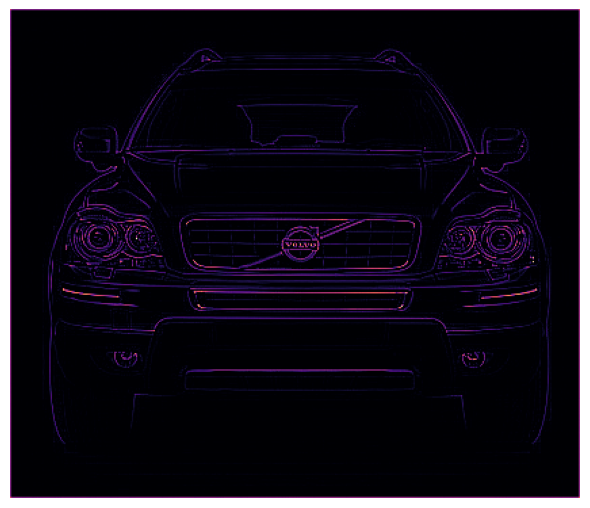

In [12]:
image_detect = tf.nn.relu(image_filter)

plt.figure(figsize=(6, 6))
plt.imshow(tf.squeeze(image_detect))
plt.axis('off')
plt.show();

#### **Maximum Pooling으로 압축**
- 이제 마지막으로 풀링 단계를 적용해보겠습니다.
 - tf.nn의 또 다른 함수인 tf.nn.pool을 사용하겠습니다.
 - 이 함수는 모델을 만들 때 사용하는 MaxPool2D 레이어와 동일한 역할을 하지만, 단순한 Python 함수이므로 직접 사용하기에 더 편리합니다.
 - 이 함수에서는 window_shape가 pooling 크기를 나타냅니다!
   - `input = image_detect`
   - `window_shape=(2, 2)`
   - `pooling_type='MAX'`


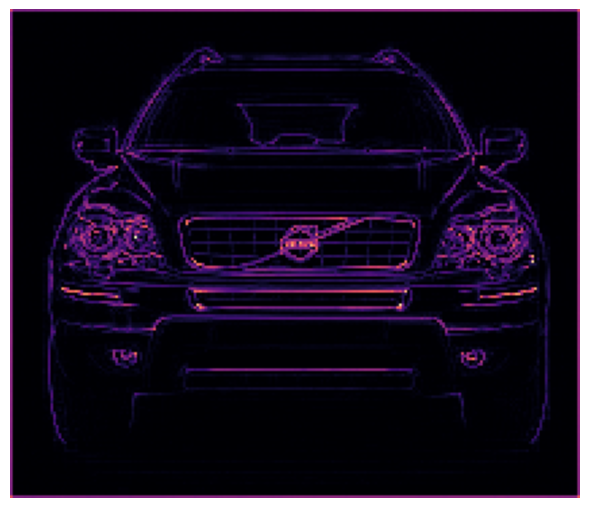

In [13]:
import tensorflow as tf

image_condense = tf.nn.pool(
    input=image_detect,
    window_shape=(2, 2),
    pooling_type='MAX',
    strides=(2, 2),
    padding='SAME',
)

plt.figure(figsize=(6, 6))
plt.imshow(tf.squeeze(image_condense))
plt.axis('off')
plt.show();

<a id="1"></a> <br>
## 5. 직접 이미지 특성 추출해보기!

1️⃣ **실험 1: 직접 이미지의 특성 추출하기**
- 예제의 과정을 본인이 원하는 커널을 만들어 진행해주세요.
 - 새로운 임의의 커널 `my_kernel`을 생성한 뒤 출력해주세요.
 - 커널을 이미지에 적용한 뒤 출력해주세요.
 - ReLU 함수를 사용해주세요.
 - Maximum pooling을 진행해주세요.
- 마지막 셀의 마크다운을 풀고, 본인이 수행한 작업이 이미지의 어떤 특성을 추출했는지 설명해주세요.

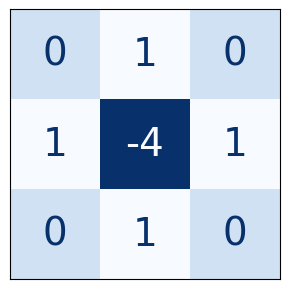

In [14]:
my_kernel = tf.constant([
    [0, 1, 0],
    [1, -4, 1],
    [0, 1, 0],
])

plt.figure(figsize=(3, 3))
show_kernel(my_kernel)

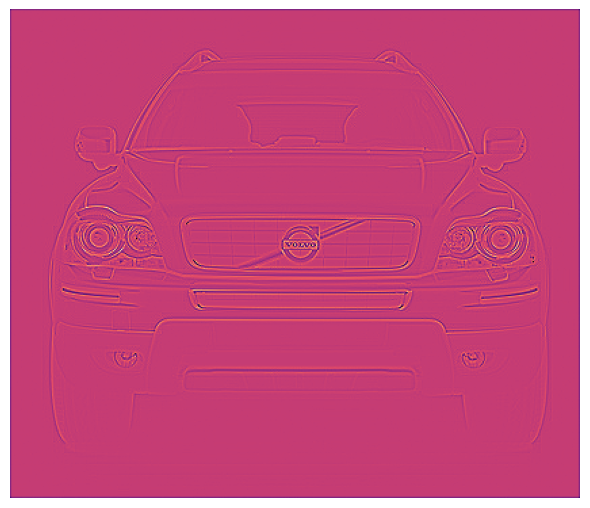

In [15]:
# 이미지를 float32 타입으로 변환하고 배치 차원을 추가합니다.
image = tf.image.convert_image_dtype(image, dtype=tf.float32)
image = tf.expand_dims(image, axis=0)

# 커널의 모양을 [높이, 너비, 입력 채널, 출력 채널] 형태로 변경합니다.
my_kernel_reshaped = tf.reshape(my_kernel, [*my_kernel.shape, 1, 1])
my_kernel_reshaped = tf.cast(my_kernel_reshaped, dtype=tf.float32)

# 커널을 이미지에 적용합니다.
image_filter_my = tf.nn.conv2d(
    input=image,
    filters=my_kernel_reshaped,
    strides=1,
    padding='SAME',
)

plt.figure(figsize=(6, 6))
plt.imshow(tf.squeeze(image_filter_my))
plt.axis('off')
plt.show();

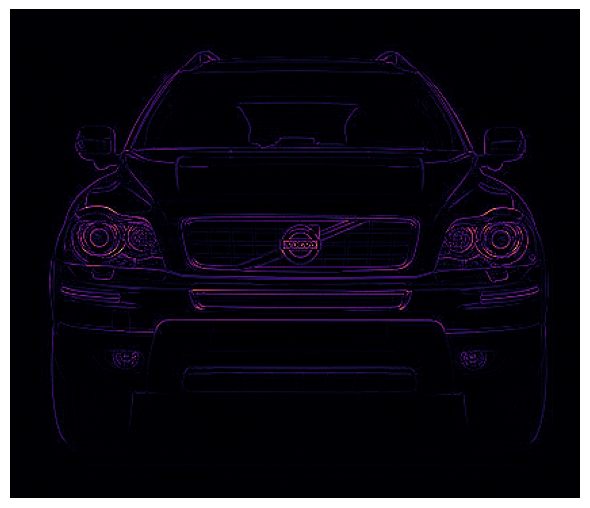

In [16]:
image_detect_my = tf.nn.relu(image_filter_my)

plt.figure(figsize=(6, 6))
plt.imshow(tf.squeeze(image_detect_my))
plt.axis('off')
plt.show();

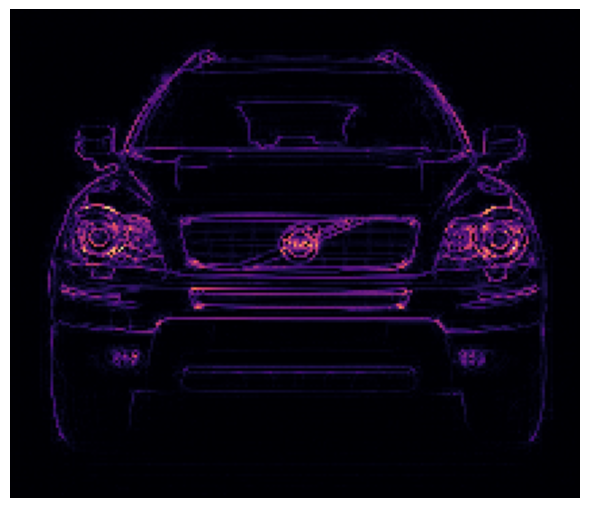

In [18]:
image_condense_my = tf.nn.pool(
    input=tf.squeeze(image_detect_my, axis=0), # Remove the extra batch dimension
    window_shape=(2, 2),
    pooling_type='MAX',
    strides=(2, 2),
    padding='SAME',
)

plt.figure(figsize=(6, 6))
plt.imshow(tf.squeeze(image_condense_my))
plt.axis('off')
plt.show();

**해당 셀의 마크 다운을 풀고 예제 코드와 어떤 점을 다르게 변형했고 이미지의 어떤 특성을 추출했는지 해석해주세요.**

* * *
## **[차이점]**
예제 코드에서는 이미지의 경계선과 같은 특징을 부각시키는 커널을 사용했습니다. 직접 실험에서는 다음과 같은 커널 `my_kernel`을 사용했습니다.

## **[해석]**
직접 사용한 `my_kernel`은 이미지의 중심 픽셀과 주변 픽셀의 차이를 강조하는 커널입니다. 이 커널은 이미지의 밝기 변화가 큰 부분, 즉 **엣지나 모서리**와 같은 특징을 잘 감지합니다. 예제에서 사용된 커널과 유사하게 이미지의 윤곽선을 추출하는 데 효과적이지만, 중앙 값이 -4로 설정되어 있어 예제 커널보다 더 강하게 중심 픽셀의 영향을 상쇄시키며 엣지를 강조하는 경향이 있습니다. ReLU 함수를 적용한 후에는 음수 값이 모두 0이 되어 어두운 영역이 사라지고, 엣지 부분만 밝게 나타나는 것을 볼 수 있습니다. Maximum Pooling을 통해 이미지 크기가 줄어들고 가장 두드러진 특징들이 강조되었습니다.